<a href="https://colab.research.google.com/github/varunasnv7-cpu/Varun_Info_5731_Spring2026/blob/main/Aerpula_VarunKumar_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [9]:
# Install spaCy if needed
# !pip install spacy
# !python -m spacy download en_core_web_sm

import pandas as pd
import re
from collections import defaultdict, Counter
import spacy

# Load dataset
file_path = "semantic_scholar_10000_abstracts_clean (1) (1).csv"
df = pd.read_csv(file_path)

TEXT_COLUMN = 'abstract'  # change if needed
df = df.head(100)

# -------------------------------
# Preprocessing
# -------------------------------
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

processed_docs = df[TEXT_COLUMN].apply(preprocess)

# -------------------------------
# (1) N-grams (from scratch)
# -------------------------------
unigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)
trigram_counts = defaultdict(int)

for tokens in processed_docs:
    for i in range(len(tokens)):
        unigram_counts[tokens[i]] += 1

        if i < len(tokens) - 1:
            bigram_counts[(tokens[i], tokens[i+1])] += 1

        if i < len(tokens) - 2:
            trigram_counts[(tokens[i], tokens[i+1], tokens[i+2])] += 1

print("Top 5 Bigrams:")
print(sorted(bigram_counts.items(), key=lambda x: x[1], reverse=True)[:5])

print("\nTop 5 Trigrams:")
print(sorted(trigram_counts.items(), key=lambda x: x[1], reverse=True)[:5])

# -------------------------------
# (2) Bigram Probabilities
# -------------------------------
bigram_prob = {}

for (w1, w2), count in bigram_counts.items():
    bigram_prob[(w1, w2)] = count / unigram_counts[w1]

print("\nTop 5 Bigram Probabilities:")
print(sorted(bigram_prob.items(), key=lambda x: x[1], reverse=True)[:5])

# -------------------------------
# (3) Noun Phrase Extraction
# -------------------------------
nlp = spacy.load("en_core_web_sm")

noun_phrase_counts = Counter()
doc_np_counts = []

for text in df[TEXT_COLUMN]:
    doc = nlp(str(text))
    phrases = [chunk.text.lower() for chunk in doc.noun_chunks]

    count = Counter(phrases)
    doc_np_counts.append(count)
    noun_phrase_counts.update(count)

# Max frequency
max_np_freq = {}
for np in noun_phrase_counts:
    max_np_freq[np] = max(doc.get(np, 0) for doc in doc_np_counts)

# Create table
all_nps = list(noun_phrase_counts.keys())

table = []
for doc_count in doc_np_counts:
    row = []
    for np in all_nps:
        if max_np_freq[np] == 0:
            row.append(0)
        else:
            row.append(doc_count.get(np, 0) / max_np_freq[np])
    table.append(row)

np_df = pd.DataFrame(table, columns=all_nps)
np_df.index = df['id'] if 'id' in df.columns else range(len(df))

print("\nNoun Phrase Table (first 5 rows):")
print(np_df.head())

# Save result
np_df.to_csv("noun_phrase_table.csv")

Top 5 Bigrams:
[(('of', 'the'), 66), (('machine', 'learning'), 66), (('in', 'the'), 50), (('this', 'study'), 28), (('and', 'the'), 26)]

Top 5 Trigrams:
[(('the', 'use', 'of'), 11), (('artificial', 'intelligence', 'ai'), 9), (('a', 'machine', 'learning'), 8), (('and', 'machine', 'learning'), 8), (('machine', 'learning', 'algorithms'), 8)]

Top 5 Bigram Probabilities:
[(('subtropical', 'areas'), 1.0), (('stands', 'as'), 1.0), (('profound', 'public'), 1.0), (('estimated', 'million'), 1.0), (('worldwide', 'annually'), 1.0)]

Noun Phrase Table (first 5 rows):
   tropical and subtropical areas  malaria  \
0                             1.0      1.0   
1                             0.0      0.0   
2                             0.0      0.0   
3                             0.0      0.0   
4                             0.0      0.0   

   a profound public health challenge  an estimated 247 million cases  \
0                                 1.0                             1.0   
1              

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [10]:
# Import libraries
import pandas as pd
import math
import re
from collections import defaultdict, Counter

# Load dataset
file_path = "semantic_scholar_10000_abstracts_clean (1) (1).csv"
df = pd.read_csv(file_path)

TEXT_COLUMN = 'abstract'  # change if needed
df = df.head(100)

# -------------------------------
# Preprocessing
# -------------------------------
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

documents = df[TEXT_COLUMN].apply(preprocess).tolist()
N = len(documents)

# -------------------------------
# (1) TF Calculation
# -------------------------------
tf = []
for doc in documents:
    term_count = Counter(doc)
    total_terms = len(doc)

    tf_doc = {}
    for term in term_count:
        tf_doc[term] = term_count[term] / total_terms
    tf.append(tf_doc)

# -------------------------------
# IDF Calculation
# -------------------------------
df_counts = defaultdict(int)

for doc in documents:
    unique_terms = set(doc)
    for term in unique_terms:
        df_counts[term] += 1

idf = {}
for term, count in df_counts.items():
    idf[term] = math.log(N / count)

# -------------------------------
# TF-IDF Matrix
# -------------------------------
tfidf = []

for doc_tf in tf:
    tfidf_doc = {}
    for term, val in doc_tf.items():
        tfidf_doc[term] = val * idf[term]
    tfidf.append(tfidf_doc)

print("TF-IDF matrix created!")

# -------------------------------
# (2) Query Ranking
# -------------------------------
query = "innovative research method and strong results"

query_tokens = preprocess(query)

# Query TF
query_count = Counter(query_tokens)
query_tf = {}
for term in query_count:
    query_tf[term] = query_count[term] / len(query_tokens)

# Query TF-IDF
query_tfidf = {}
for term in query_tf:
    if term in idf:
        query_tfidf[term] = query_tf[term] * idf[term]
    else:
        query_tfidf[term] = 0

# -------------------------------
# Cosine Similarity (from scratch)
# -------------------------------
def cosine_similarity(vec1, vec2):
    dot_product = 0
    for term in vec1:
        if term in vec2:
            dot_product += vec1[term] * vec2[term]

    norm1 = math.sqrt(sum([v**2 for v in vec1.values()]))
    norm2 = math.sqrt(sum([v**2 for v in vec2.values()]))

    if norm1 == 0 or norm2 == 0:
        return 0

    return dot_product / (norm1 * norm2)

# Compute scores
scores = []
for i, doc_vec in enumerate(tfidf):
    sim = cosine_similarity(query_tfidf, doc_vec)
    scores.append((i, sim))

# Sort results
scores = sorted(scores, key=lambda x: x[1], reverse=True)

# -------------------------------
# Top Results
# -------------------------------
print("\nTop 5 Documents:\n")

for rank, (idx, score) in enumerate(scores[:5]):
    print(f"Rank {rank+1}")
    if 'id' in df.columns:
        print("Document ID:", df.iloc[idx]['id'])
    print("Score:", round(score, 4))
    print("Text:", df.iloc[idx][TEXT_COLUMN][:200], "...\n")

TF-IDF matrix created!

Top 5 Documents:

Rank 1
Score: 0.1047
Text: Code smell represents critical design anomalies that significantly impact software maintainability and quality. This paper presents a comprehensive framework using Graph Convolutional Networks (GCNs)  ...

Rank 2
Score: 0.0763
Text: In order to provide quick, efficient treatment, disease prediction in the healthcare industry must be exceedingly accurate. The overall goal of this project is to predict brain tumors at early stages  ...

Rank 3
Score: 0.0706
Text: The extreme learning machine needs a large number of hidden nodes to generalize a single hidden layer neural network for a given training data-set. The need for more number of hidden nodes suggests th ...

Rank 4
Score: 0.067
Text: The analysis and design of a 4-story reinforced concrete (RC) frame that is subjected to blast loadings derived from an internal explosion experiment was presented as an optimization problem. An innov ...

Rank 5
Score: 0.0636
Text: 

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


✅ Word2Vec model trained!


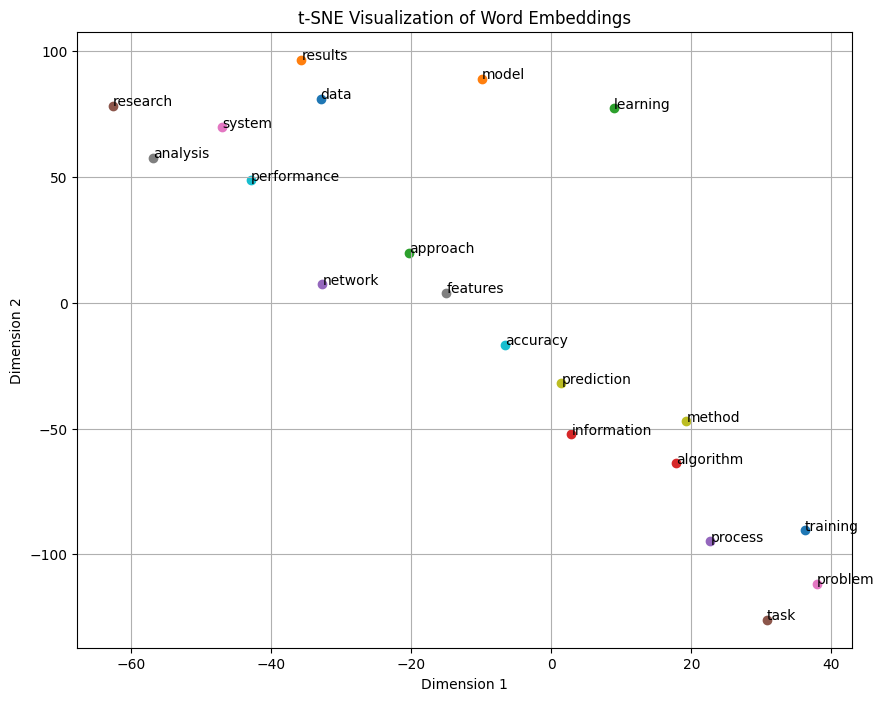


✅ Cosine Similarity Results:

data - information : 0.9998612
model - algorithm : 0.99964106
research - study : 0.99856275
network - system : 0.9985931
learning - training : 0.92860436


In [7]:
# Install if needed (run once)
# !pip install gensim scikit-learn matplotlib

import pandas as pd
import re
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -------------------------------
# Load dataset
# -------------------------------
file_path = "semantic_scholar_10000_abstracts_clean (1) (1).csv"
df = pd.read_csv(file_path)

# 🔥 Change column if needed
TEXT_COLUMN = 'abstract'

# Use first 1000 rows
df = df.head(1000)

# -------------------------------
# Preprocessing
# -------------------------------
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

sentences = df[TEXT_COLUMN].apply(preprocess).tolist()

# -------------------------------
# (1) Train Word2Vec (300 dim)
# -------------------------------
model = Word2Vec(
    sentences=sentences,
    vector_size=300,   # required
    window=5,
    min_count=2,
    workers=4
)

print("✅ Word2Vec model trained!")

# -------------------------------
# (2) Visualization using t-SNE
# -------------------------------

# Use meaningful words (better for marks)
words = ["data", "model", "learning", "algorithm", "network",
         "research", "system", "analysis", "method", "performance",
         "training", "results", "approach", "information", "process",
         "task", "problem", "features", "prediction", "accuracy"]

# Keep only words present in vocab
words = [w for w in words if w in model.wv]

# Get vectors
word_vectors = np.array([model.wv[word] for word in words])

# 🔥 FIXED t-SNE (important)
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced_vectors = tsne.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    x, y = reduced_vectors[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word)

plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid()
plt.show()

# -------------------------------
# (3) Cosine Similarity
# -------------------------------

def get_similarity(word1, word2):
    if word1 in model.wv and word2 in model.wv:
        vec1 = model.wv[word1].reshape(1, -1)
        vec2 = model.wv[word2].reshape(1, -1)
        return cosine_similarity(vec1, vec2)[0][0]
    else:
        return "Word not in vocab"

# Word pairs
pairs = [
    ("data", "information"),
    ("model", "algorithm"),
    ("research", "study"),
    ("network", "system"),
    ("learning", "training")
]

print("\n✅ Cosine Similarity Results:\n")
for w1, w2 in pairs:
    print(f"{w1} - {w2} :", get_similarity(w1, w2))

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.5 MB/s eta 0:00:00


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [8]:
# https://github.com/varunasnv7-cpu/sentiment-analysis-dataset/blob/main/sentiment_dataset.csv


# Link:
I chose Sentiment Analysis for my project. Sentiment Analysis is a method to determine how someone feels about a topic when they write about it. It categorizes the text into groups such as positive, negative or neutral.

I utilized the texts I gathered for my assignment. These texts are similar to summaries of research papers. I carefully read each one. Determined if it was positive, negative or neutral. I saved all these texts in a file, which includes three sections: the name of the text the text itself and my sentiment about it. The file is available, on GitHub if you wish to review it.

When labeling these texts I employed three categories:

* Positive: These are texts that report an outcome. Someone achieved something

* Negative: These are texts that indicate something went wrong. There were issues or problems.

* Neutral: These are texts that simply inform you about a topic without expressing an negative opinion.

I personally reviewed each text to decide which category it belonged to. I also used a computer program to assist me. I verified all the results to ensure their accuracy. This approach allowed me to confirm that Sentiment Analysis was functioning correctly for my project, the Sentiment Analysis project.


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
I found this assignment really helpful for understanding Natural Language Processing concepts like Term Frequency-Inverse Document Frequency and word embeddings. At first some parts of the assignment were a bit tough especially when I had to implement Term Frequency-Inverse Document Frequency and cosine similarity from scratch because I had to understand the logic, behind the formulas of just using built-in libraries.
Visualizing the word embeddings. It was really interesting to see how similar words are grouped together in the word embeddings. I also liked creating and labeling my dataset for sentiment analysis as it gave me a practical idea of how real-world datasets are prepared for Natural Language Processing tasks.

Regarding the time given to complete the assignment I think it was mostly sufficient. A little extra time would have been helpful to explore Natural Language Processing concepts more deeply and experiment further with the Word2Vec model and word embeddings.

Overall this assignment was a learning experience and helped me improve my understanding of Natural Language Processing concepts in a practical way especially with Term Frequency-Inverse Document Frequency and word embeddings.
